# Differential Cell Type Proportion Testing

Tests whether cell type proportions (cluster abundances) differ significantly between two sample groups in a single-cell experiment with **3 vs 2 biological replicates**.

## Methods implemented

| # | Method | Reference | Key idea |
|---|--------|-----------|----------|
| 1 | **propeller** (logit) | Phipson et al. 2022, *Bioinformatics* | Logit-transform proportions → limma moderated t-test; borrows variance across clusters |
| 2 | **propeller** (arcsin) | Phipson et al. 2022, *Bioinformatics* | Arcsin-sqrt-transform proportions → limma; variance-stabilising alternative |
| 3 | **Beta regression** | Ferrari & Cribari-Neto 2004 | Models proportions directly on (0,1); handles skew; per-cluster GLM |
| 4 | **Wilcoxon rank-sum** | Non-parametric baseline | Distribution-free; appropriate for n=3 vs n=2 but low power |
| 5 | **Permutation test** | Bespoke | Permutes sample-group labels; exact p-values; no distributional assumptions |
| 6 | **scCODA** | Büttner et al. 2021, *Nature Communications* | Bayesian Multinomial-Dirichlet model; treats data as compositional; requires reference cell type |
| 7 | **sccomp** | Mangiola et al. 2023, *PNAS* | Dirichlet-multinomial GLM; tests both differential composition **and** variability; outlier-robust; no reference cell type required |

## Data
- **Object**: `../../../../workdir/PDACmyc.SeuratV5.Rds`
- **Cluster annotations**: `clusterName` metadata column
- **Sample IDs**: `sampleName` metadata column
- **Group assignment**: `meta_Group` metadata column
- **Design**: 3 replicates in group A, 2 replicates in group B (unbalanced)

## References
- Phipson et al. (2022) propeller. *Bioinformatics*. https://doi.org/10.1093/bioinformatics/btac582
- Büttner et al. (2021) scCODA. *Nature Communications*. https://doi.org/10.1038/s41467-021-27150-6
- Mangiola et al. (2023) sccomp. *PNAS*. https://doi.org/10.1073/pnas.2203828120
- Simmons (2022) benchmarking. *bioRxiv*. https://doi.org/10.1101/2022.02.04.479123
- Dann et al. (2021) Milo. *Nature Biotechnology*. https://doi.org/10.1038/s41587-021-01033-z

In [1]:
import sys
print(sys.executable)

/nemo/stp/babs/working/boeings/package_caches/venv/single_cell_venv_python310/bin/python


In [2]:
#!pip install anndata

In [3]:
# Load R magic extension
%load_ext rpy2.ipython

import os
import scanpy as sc
import anndata
print(f"scanpy version: {sc.__version__}")
print(f"anndata version: {anndata.__version__}")

- Project '/nemo/stp/babs/working/boeings/Projects/evang/roderik.kortlever/559_scRNAseq_il33myc/scripts/il33myc/analyses/ad_hoc_figures' loaded. [renv 1.1.7]
scanpy version: 1.11.5
anndata version: 0.11.4


/tmp/ipykernel_1564232/2953536773.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy version: {sc.__version__}")


In [4]:
%%R
list.files("../../../../workdir/")

 [1] "data"                     "GSEA"                    
 [3] "il33myc.bioLOGIC.Robj"    "il33myc.Seurat.Robj"     
 [5] "il33myc.SeuratV5.obj.Rds" "liana.res.csv"           
 [7] "rB.rB_dBP559.slurm"       "rB.rDGE_dBP559.slurm"    
 [9] "rC.rB_dBP559.slurm"       "rC.rDGE_dBP559.slurm"    
[11] "sc_PartC_Analysis.html"   "temp"                    


In [5]:
# Data
seuratRDSfile = '../../../../workdir/il33myc.SeuratV5.obj.Rds'

In [6]:
%%R -i seuratRDSfile
print(seuratRDSfile)

[1] "../../../../workdir/il33myc.SeuratV5.obj.Rds"


In [7]:
%%R

#utils::assignInNamespace("renv_sysreqs_check", function(...) invisible(NULL), ns = "renv")
# renv::install("bioc::edgeR")

NULL


In [8]:
%%R
renv::restore()

- The library is already synchronized with the lockfile.


In [9]:
%%R
pkgs_to_check <- list(
  edgeR = "edgeR",
  limma   = "limma",
  speckle = "speckle",
  sccomp  = "sccomp"
)

missing <- names(Filter(function(pkg) !requireNamespace(pkg, quietly = TRUE), pkgs_to_check))

missing

character(0)


Registered S3 methods overwritten by 'Seqinfo':
  method                from        
  as.data.frame.Seqinfo GenomeInfoDb
  merge.Seqinfo         GenomeInfoDb
  summary.Seqinfo       GenomeInfoDb
In addition: Warning messages:
1: replacing previous import ‘GenomeInfoDb::seqinfo<-’ by ‘GenomicRanges::seqinfo<-’ when loading ‘SummarizedExperiment’ 
2: replacing previous import ‘GenomeInfoDb::seqinfo’ by ‘GenomicRanges::seqinfo’ when loading ‘SummarizedExperiment’ 
3: replacing previous import ‘GenomeInfoDb::seqnames’ by ‘GenomicRanges::seqnames’ when loading ‘SummarizedExperiment’ 
4: replacing previous import ‘GenomeInfoDb::seqnames<-’ by ‘GenomicRanges::seqnames<-’ when loading ‘SummarizedExperiment’ 
5: replacing previous import ‘S4Arrays::makeNindexFromArrayViewport’ by ‘DelayedArray::makeNindexFromArrayViewport’ when loading ‘SummarizedExperiment’ 
6: multiple methods tables found for ‘seqinfo’ 
7: multiple methods tables found for ‘seqinfo<-’ 
8: multiple methods tables found for ‘

In [10]:
%%R

pkgs_to_check <- list(
  edgeR = "edgeR",
  limma   = "limma",
  speckle = "speckle",
  sccomp  = "sccomp"
)

missing <- names(Filter(function(pkg) !requireNamespace(pkg, quietly = TRUE), pkgs_to_check))
print(missing)


if (length(missing) > 0) {
  missing <- paste0("bioc::", missing)
  message("Installing missing packages: ", paste(missing, collapse = ", "))
  renv::install(unname(pkgs_to_check[missing]))
  renv::snapshot(prompt = FALSE)
} else {
  message("All packages already installed.")
}

character(0)


All packages already installed.


In [11]:
%%R
# ── 0. Load R packages via renv ───────────────────────────────────────────────
# renv::activate()   # activates the project renv, using RENV_PATHS_* env vars
renv::restore()  # installs any missing packages from the lockfile

pkgs <- c('Seurat', 'dplyr', 'tidyr', 'ggplot2', 'patchwork',
          'betareg', 'scales', 'ggrepel', 'RColorBrewer',
          'limma', 'edgeR', 'speckle', 'sccomp')

# Install any packages not yet available
missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]

print(missing)

if (length(missing) > 0) {
  message("Installing missing packages: ", paste(missing, collapse = ", "))
  renv::install(missing)
  renv::snapshot()
}

for (p in pkgs)
  suppressPackageStartupMessages(library(p, character.only = TRUE))

# Snapshot the environment after installing
renv::snapshot(prompt = FALSE)

cat('All R packages loaded.\n')
cat('R version:', R.version$version.string, '\n')

- The library is already synchronized with the lockfile.
character(0)
- The lockfile is already up to date.
All R packages loaded.
R version: R version 4.5.0 (2025-04-11) 


## 0b. Python environment for scCODA

scCODA is implemented in Python (via the `pertpy` package, which absorbed the original `scCODA` library). We install it here and run it in a standard Python cell later, exporting results to CSV for integration with the R summary table.

In [12]:
# ── Install pertpy (contains scCODA) if not already present ──────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pertpy', '-q'], check=False)

import importlib
if importlib.util.find_spec('pertpy') is not None:
    print('pertpy available — scCODA will run.')
else:
    print('pertpy not available — scCODA cell will be skipped.')

pertpy available — scCODA will run.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Load data and inspect

In [13]:
%%R
# ── Load Seurat object ────────────────────────────────────────────────────────
if (file.exists(seuratRDSfile)){
    seu <- readRDS(seuratRDSfile)
} else {
    print("No such file.")
}


cat('Seurat object loaded.\n')
print(seu)

Seurat object loaded.
An object of class Seurat 
64570 features across 47054 samples within 2 assays 
Active assay: sketch (32285 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: RNA
 9 dimensional reductions calculated: pca.sketch, umap.sketch.unintegrated, harmony.sketch, umap.harmony.sketch, tsne.harmony.sketch, harmony, pca, tsne, umap


In [14]:
%%R
names(seu@meta.data)

 [1] "orig_ident"                                         
 [2] "nCount_RNA"                                         
 [3] "nFeature_RNA"                                       
 [4] "orig_ident_1"                                       
 [5] "sampleName"                                         
 [6] "sampleID"                                           
 [7] "method"                                             
 [8] "percent_mt"                                         
 [9] "S_Score"                                            
[10] "G2M_Score"                                          
[11] "Phase"                                              
[12] "old_ident"                                          
[13] "leverage_score"                                     
[14] "unintegrated_clusters_sketch"                       
[15] "testResSketch_0_2"                                  
[16] "testResSketch_0_3"                                  
[17] "testResSketch_0_4"                                

In [15]:
%%R
unique(seu@meta.data$meta_Treatment)

[1] "Ctrl" "Il33"


In [16]:
%%R
unique(seu@meta.data$meta_Group)

NULL


In [17]:
%%R
# Project specific modification
# Create meta_Group

seu@meta.data$meta_Group <- seu@meta.data$meta_Treatment

#seu@meta.data[["meta_Group"]] = ""
#seu@meta.data[grep("MycON",seu@meta.data$sampleName), "meta_Group"] <- "MycON"
#seu@meta.data[grep("MycOff",seu@meta.data$sampleName), "meta_Group"] <- "MycOff"
#unique(seu@meta.data$meta_Group)

In [18]:
%%R
# ── Inspect key metadata columns ──────────────────────────────────────────────
meta <- seu@meta.data

cat('\n--- clusterName ---\n')
print(table(meta$clusterName))

cat('\n--- sampleName ---\n')
print(table(meta$sampleName))

cat('\n--- meta_Group ---\n')
print(table(meta$meta_Group))

cat('\n--- Sample x Group cross-table ---\n')
unique(seu@meta.data$sampleName)


--- clusterName ---

     ActVEndoI     ActVEndoII            AdT    AlvCapEndoI   AlvCapEndoII 
           573            484           2201            850            789 
      AlvMacro     AT1AT2Club        BasMast             BI            BII 
          3939            596            298            977            722 
 CyclingcellsI CyclingcellsII         DendrI        DendrII          EndoI 
           396            131           3552            473           8440 
        EndoII            Ery          Fibro           ILC1           ILC2 
           913            856            584            786            221 
       InFibro       InnLymph     LymCapEndo          Lymph          Macro 
           518            399           4804             60            889 
          Mega           Mono      MuCillEpi        NeutroI       NeutroII 
          2518           3083            154           3986            732 
        Nklike            pDC          PeriI         PeriII 
     

## 2. Build proportion table

Compute per-sample cell type proportions — the fundamental input for all downstream tests.

In [20]:
%%R
# ── Sample-level metadata (one row per sample) ────────────────────────────────
sample_meta <- meta %>%
  select(sampleName, meta_Group) %>%
  distinct() %>%
  arrange(meta_Group, sampleName)

cat('Sample metadata:\n')
print(sample_meta)

# Verify group sizes
group_sizes <- table(sample_meta$meta_Group)
cat('\nReplicates per group:\n')
print(group_sizes)

# Extract group labels for downstream use
groups  <- unique(sample_meta$meta_Group)
group_A <- groups[1]
group_B <- groups[2]
cat(sprintf('\nGroup A: %s (%d replicates)\n', group_A, group_sizes[group_A]))
cat(sprintf('Group B: %s (%d replicates)\n', group_B, group_sizes[group_B]))

Sample metadata:
                       sampleName meta_Group
AAACCCAAGACGTCCC Myc2W_Ctril_CRE5       Ctrl
AAACCCAAGACGCCAA  Myc2W_Ctrl_CRE1       Ctrl
AAACCCAAGCAGAAAG  Myc2W_Ctrl_CRE2       Ctrl
AAACCCAAGAAGATCT  Myc2W_Ctrl_CRE3       Ctrl
AAACCCAAGAGCATAT  Myc2W_Il33_CRE6       Il33
AAACCCAAGAAGTATC  Myc2W_Il33_CRE7       Il33
AAACCCAAGAGGACTC  Myc2W_Il33_CRE8       Il33
AAACCCAAGTCTAGCT  Myc2W_Il33_CRE9       Il33

Replicates per group:

Ctrl Il33 
   4    4 

Group A: Ctrl (4 replicates)
Group B: Il33 (4 replicates)


In [21]:
%%R
# ── Cell counts per sample x cluster ─────────────────────────────────────────
count_mat <- meta %>%
  group_by(sampleName, clusterName) %>%
  summarise(n_cells = n(), .groups = 'drop') %>%
  pivot_wider(names_from = clusterName, values_from = n_cells, values_fill = 0)

count_df  <- as.data.frame(count_mat)
rownames(count_df) <- count_df$sampleName
count_df  <- count_df[, -1]
count_mx  <- as.matrix(count_df)

cat('Count matrix (samples x clusters):\n')
print(count_mx)

# ── Proportion matrix ─────────────────────────────────────────────────────────
prop_mx <- sweep(count_mx, 1, rowSums(count_mx), FUN = '/')

cat('\nProportion matrix (samples x clusters):\n')
print(round(prop_mx, 4))

Count matrix (samples x clusters):
                 AT1AT2Club ActVEndoI ActVEndoII AdT AlvCapEndoI AlvCapEndoII
Myc2W_Ctril_CRE5         19        25         15 143          50           31
Myc2W_Ctrl_CRE1         160        80         56 228         158          118
Myc2W_Ctrl_CRE2         170        61         38 382         152          119
Myc2W_Ctrl_CRE3          56        46         33 244          63           41
Myc2W_Il33_CRE6          72        83         88 381         178          201
Myc2W_Il33_CRE7          51        68         45 322          76           80
Myc2W_Il33_CRE8          28       126        111 304          65           94
Myc2W_Il33_CRE9          40        84         98 197         108          105
                 AlvMacro  BI BII BasMast CyclingcellsI CyclingcellsII DendrI
Myc2W_Ctril_CRE5      351   2  12      21           109             11    279
Myc2W_Ctrl_CRE1       691 139  39      15            63              4    171
Myc2W_Ctrl_CRE2       764  98

In [22]:
%%R
# ── Long-format proportion table (used by multiple methods) ───────────────────
prop_long <- as.data.frame(prop_mx) %>%
  tibble::rownames_to_column('sampleName') %>%
  pivot_longer(-sampleName, names_to = 'clusterName', values_to = 'proportion') %>%
  left_join(sample_meta, by = 'sampleName')

cat('Long-format proportion table (first 12 rows):\n')
print(head(prop_long, 12))

# ── Export count matrix to CSV for scCODA (Python) ───────────────────────────
count_export <- as.data.frame(count_mx) %>%
  tibble::rownames_to_column('sampleName') %>%
  left_join(sample_meta, by = 'sampleName')

write.csv(count_export, '/tmp/sccoda_counts.csv', row.names = FALSE)
cat('\nCount matrix exported to /tmp/sccoda_counts.csv for scCODA.\n')

Long-format proportion table (first 12 rows):
# A tibble: 12 × 4
   sampleName       clusterName    proportion meta_Group
   <chr>            <chr>               <dbl> <chr>     
 1 Myc2W_Ctril_CRE5 AT1AT2Club       0.00482  Ctrl      
 2 Myc2W_Ctril_CRE5 ActVEndoI        0.00634  Ctrl      
 3 Myc2W_Ctril_CRE5 ActVEndoII       0.00380  Ctrl      
 4 Myc2W_Ctril_CRE5 AdT              0.0363   Ctrl      
 5 Myc2W_Ctril_CRE5 AlvCapEndoI      0.0127   Ctrl      
 6 Myc2W_Ctril_CRE5 AlvCapEndoII     0.00786  Ctrl      
 7 Myc2W_Ctril_CRE5 AlvMacro         0.0890   Ctrl      
 8 Myc2W_Ctril_CRE5 BI               0.000507 Ctrl      
 9 Myc2W_Ctril_CRE5 BII              0.00304  Ctrl      
10 Myc2W_Ctril_CRE5 BasMast          0.00533  Ctrl      
11 Myc2W_Ctril_CRE5 CyclingcellsI    0.0276   Ctrl      
12 Myc2W_Ctril_CRE5 CyclingcellsII   0.00279  Ctrl      

Count matrix exported to /tmp/sccoda_counts.csv for scCODA.


## 3. Visualise proportions

Stacked bar chart and dot plot before any statistical testing.

Saved: cell_proportions_overview.png


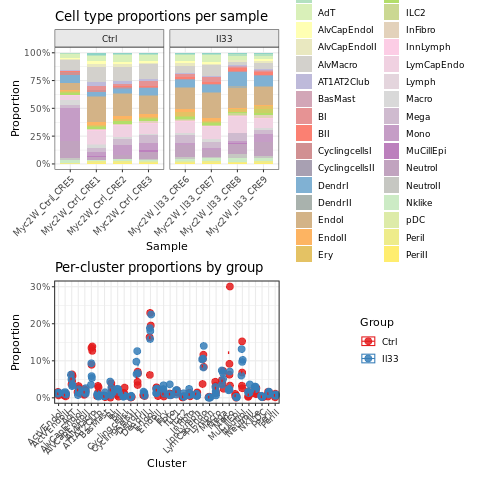

In [23]:
%%R
options(repr.plot.width = 14, repr.plot.height = 5)

n_clusters <- length(unique(prop_long$clusterName))
pal <- colorRampPalette(RColorBrewer::brewer.pal(min(n_clusters, 12), 'Set3'))(n_clusters)
names(pal) <- sort(unique(prop_long$clusterName))

# ── Stacked bar chart ─────────────────────────────────────────────────────────
p_stack <- ggplot(prop_long,
                  aes(x = sampleName, y = proportion, fill = clusterName)) +
  geom_bar(stat = 'identity', width = 0.75) +
  scale_fill_manual(values = pal) +
  facet_grid(~ meta_Group, scales = 'free_x', space = 'free_x') +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(title = 'Cell type proportions per sample',
       x = 'Sample', y = 'Proportion', fill = 'Cluster') +
  theme_bw(base_size = 11) +
  theme(axis.text.x  = element_text(angle = 45, hjust = 1),
        legend.position = 'right',
        strip.background = element_rect(fill = '#E8E8E8'))

# ── Dot plot: proportion per cluster, coloured by group ───────────────────────
p_dot <- ggplot(prop_long,
                aes(x = clusterName, y = proportion, colour = meta_Group)) +
  geom_jitter(width = 0.15, size = 3, alpha = 0.85) +
  stat_summary(aes(group = meta_Group), fun = mean,
               geom = 'crossbar', width = 0.4, linewidth = 0.5,
               position = position_dodge(width = 0.4)) +
  scale_colour_manual(values = c('#E41A1C', '#377EB8')) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(title = 'Per-cluster proportions by group',
       x = 'Cluster', y = 'Proportion', colour = 'Group') +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p_stack / p_dot)

ggsave('../../../../html_local/report_figures/cell_proportions_overview.png',
       p_stack / p_dot, width = 14, height = 10, dpi = 200, bg = 'white')
cat('Saved: cell_proportions_overview.png\n')

## 4. Method 1 — propeller (logit transform)

**propeller** [Phipson et al. 2022] logit-transforms per-sample proportions and applies limma's empirical Bayes moderated t-test. Variance is borrowed across clusters, which is particularly beneficial with small replicate numbers (n = 3 vs 2). The logit transform is the default and generally preferred.

> Phipson B, Sim CB, Porrello ER, et al. propeller: testing for differences in cell type proportions in single cell data. *Bioinformatics*. 2022. https://doi.org/10.1093/bioinformatics/btac582

In [24]:
%%R
# ── propeller requires: clusters, sample, group vectors (one entry per cell) ──
clusters_vec <- meta$clusterName
sample_vec   <- meta$sampleName
group_vec    <- meta$meta_Group

res_propeller_logit <- propeller(
  clusters  = clusters_vec,
  sample    = sample_vec,
  group     = group_vec,
  transform = 'logit',
  trend     = FALSE,
  robust    = FALSE
)

cat('=== propeller results (logit transform) ===\n')
print(res_propeller_logit)

=== propeller results (logit transform) ===
               BaselineProp.clusters BaselineProp.Freq PropMean.Ctrl
CyclingcellsI          CyclingcellsI       0.008415863   0.014561319
NeutroII                    NeutroII       0.015556595   0.007791805
BII                              BII       0.015344073   0.008219384
Mono                            Mono       0.065520466   0.121872096
AlvMacro                    AlvMacro       0.083712331   0.122280294
Lymph                          Lymph       0.001275131   0.001865478
Ery                              Ery       0.018191865   0.010276471
AT1AT2Club                AT1AT2Club       0.012666298   0.019680676
Nklike                        Nklike       0.022676074   0.016231452
ILC2                            ILC2       0.004696731   0.002565544
CyclingcellsII        CyclingcellsII       0.002784035   0.001842358
DendrI                        DendrI       0.075487737   0.053429173
ActVEndoII                ActVEndoII       0.010286054   0.

Performing logit transformation of proportions
group variable has 2 levels, t-tests will be performed


## 5. Method 2 — propeller (arcsin-sqrt transform)

The arcsin-square-root transformation is a classical variance-stabilising transform for proportions. Useful when proportions are near 0 or 1 where logit can be unstable.

In [25]:
%%R
res_propeller_asin <- propeller(
  clusters  = clusters_vec,
  sample    = sample_vec,
  group     = group_vec,
  transform = 'asin',
  trend     = FALSE,
  robust    = FALSE
)

cat('=== propeller results (arcsin-sqrt transform) ===\n')
print(res_propeller_asin)

=== propeller results (arcsin-sqrt transform) ===
               BaselineProp.clusters BaselineProp.Freq PropMean.Ctrl
AlvMacro                    AlvMacro       0.083712331   0.122280294
BII                              BII       0.015344073   0.008219384
CyclingcellsI          CyclingcellsI       0.008415863   0.014561319
DendrI                        DendrI       0.075487737   0.053429173
Nklike                        Nklike       0.022676074   0.016231452
Ery                              Ery       0.018191865   0.010276471
NeutroII                    NeutroII       0.015556595   0.007791805
AT1AT2Club                AT1AT2Club       0.012666298   0.019680676
Mono                            Mono       0.065520466   0.121872096
ActVEndoII                ActVEndoII       0.010286054   0.007339780
DendrII                      DendrII       0.010052280   0.006921968
BasMast                      BasMast       0.006333149   0.003855933
Macro                          Macro       0.01889318

Performing arcsin square root transformation of proportions
group variable has 2 levels, t-tests will be performed


## 6. Method 3 — Beta regression

Beta regression [Ferrari & Cribari-Neto 2004] models proportions directly on the (0, 1) interval using a Beta-distributed response. It naturally handles the bounded, skewed nature of proportions without requiring a transformation. A separate model is fit per cluster.

**Note on small n**: With only 3 + 2 = 5 observations per cluster, beta regression is at the edge of feasibility. Results should be interpreted cautiously and cross-checked with propeller.

In [26]:
%%R
library(betareg)

# Smithson & Verkuilen (2006) squeeze: (y*(n-1) + 0.5) / n
squeeze_prop <- function(p, n) (p * (n - 1) + 0.5) / n

run_betareg <- function(prop_long_df) {
  clusters <- unique(prop_long_df$clusterName)
  n_total  <- nrow(sample_meta)

  results <- lapply(clusters, function(cl) {
    df <- prop_long_df %>%
      filter(clusterName == cl) %>%
      mutate(
        prop_sq = squeeze_prop(proportion, n_total),
        group_f = factor(meta_Group)
      )

    if (var(df$proportion) == 0) {
      return(data.frame(
        clusterName = cl, estimate = NA, std_error = NA,
        z_value = NA, p_value = NA, method = 'betareg',
        note = 'zero variance — skipped'
      ))
    }

    tryCatch({
      fit <- betareg(prop_sq ~ group_f, data = df, link = 'logit')
      coef_tbl <- summary(fit)$coefficients$mean
      if (nrow(coef_tbl) < 2) {
        return(data.frame(
          clusterName = cl, estimate = NA, std_error = NA,
          z_value = NA, p_value = NA, method = 'betareg',
          note = 'model did not converge'
        ))
      }
      data.frame(
        clusterName = cl,
        estimate    = coef_tbl[2, 'Estimate'],
        std_error   = coef_tbl[2, 'Std. Error'],
        z_value     = coef_tbl[2, 'z value'],
        p_value     = coef_tbl[2, 'Pr(>|z|)'],
        method      = 'betareg',
        note        = 'ok'
      )
    }, error = function(e) {
      data.frame(
        clusterName = cl, estimate = NA, std_error = NA,
        z_value = NA, p_value = NA, method = 'betareg',
        note = paste('error:', conditionMessage(e))
      )
    })
  })

  res <- do.call(rbind, results)
  res$p_adj <- p.adjust(res$p_value, method = 'BH')
  res[order(res$p_value), ]
}

res_betareg <- run_betareg(prop_long)

cat('=== Beta regression results ===\n')
print(res_betareg)

=== Beta regression results ===
      clusterName    estimate   std_error    z_value      p_value  method note
9             BII  0.14474041 0.033724354  4.2918662 1.771777e-05 betareg   ok
7        AlvMacro -0.45352374 0.106920154 -4.2417049 2.218283e-05 betareg   ok
31         Nklike  0.12744253 0.041560443  3.0664381 2.166257e-03 betareg   ok
17            Ery  0.14806596 0.057158477  2.5904462 9.585161e-03 betareg   ok
3      ActVEndoII  0.06306602 0.024422350  2.5823077 9.814203e-03 betareg   ok
11  CyclingcellsI -0.13124620 0.053189812 -2.4675065 1.360578e-02 betareg   ok
13         DendrI  0.27574280 0.115672934  2.3838144 1.713424e-02 betareg   ok
14        DendrII  0.06266152 0.028853511  2.1717122 2.987737e-02 betareg   ok
30       NeutroII  0.14825722 0.068552223  2.1626902 3.056501e-02 betareg   ok
1      AT1AT2Club -0.15168420 0.070807787 -2.1421965 3.217767e-02 betareg   ok
12 CyclingcellsII  0.02201802 0.011365387  1.9372874 5.271023e-02 betareg   ok
28      MuCillEpi -0

In addition: Warning messages:
1: In betareg.fit(X, Y, Z, weights, offset, link, link.phi, type, control,  :
  optimization failed to converge
2: In betareg.fit(X, Y, Z, weights, offset, link, link.phi, type, control,  :
  optimization failed to converge
3: In betareg.fit(X, Y, Z, weights, offset, link, link.phi, type, control,  :
  optimization failed to converge
4: In betareg.fit(X, Y, Z, weights, offset, link, link.phi, type, control,  :
  optimization failed to converge
5: In betareg.fit(X, Y, Z, weights, offset, link, link.phi, type, control,  :
  optimization failed to converge


## 7. Method 4 — Wilcoxon rank-sum test

A non-parametric baseline. With n = 3 vs n = 2, the minimum achievable p-value is 0.1 (two-sided), so this test has very limited power. Included for completeness and as a sanity check.

In [27]:
%%R
run_wilcoxon <- function(prop_long_df, sample_meta_df) {
  clusters <- unique(prop_long_df$clusterName)

  results <- lapply(clusters, function(cl) {
    df <- prop_long_df %>% filter(clusterName == cl)

    grp_A <- df %>% filter(meta_Group == group_A) %>% pull(proportion)
    grp_B <- df %>% filter(meta_Group == group_B) %>% pull(proportion)

    wt <- tryCatch(
      wilcox.test(grp_A, grp_B, exact = FALSE, alternative = 'two.sided'),
      warning = function(w) suppressWarnings(
        wilcox.test(grp_A, grp_B, exact = FALSE, alternative = 'two.sided')
      )
    )

    data.frame(
      clusterName  = cl,
      mean_A       = mean(grp_A),
      mean_B       = mean(grp_B),
      W_statistic  = wt$statistic,
      p_value      = wt$p.value,
      method       = 'wilcoxon'
    )
  })

  res <- do.call(rbind, results)
  res$p_adj <- p.adjust(res$p_value, method = 'BH')
  res[order(res$p_value), ]
}

res_wilcoxon <- run_wilcoxon(prop_long, sample_meta)

cat('=== Wilcoxon rank-sum results ===\n')
cat('NOTE: With n=3 vs n=2, minimum achievable two-sided p-value is 0.1.\n\n')
print(res_wilcoxon)

=== Wilcoxon rank-sum results ===
NOTE: With n=3 vs n=2, minimum achievable two-sided p-value is 0.1.

       clusterName      mean_A       mean_B W_statistic    p_value   method
W8             BII 0.008219384 0.0196609675           0 0.03038282 wilcoxon
W2      ActVEndoII 0.007339780 0.0120840730           1 0.06060197 wilcoxon
W6        AlvMacro 0.122280294 0.0600827846          15 0.06060197 wilcoxon
W10  CyclingcellsI 0.014561319 0.0043617180          15 0.06060197 wilcoxon
W16            Ery 0.010276471 0.0224750244           2 0.11235120 wilcoxon
W26           Mono 0.121872096 0.0342080198          14 0.11235120 wilcoxon
W30         Nklike 0.016231452 0.0269583269           2 0.11235120 wilcoxon
W       AT1AT2Club 0.019680676 0.0071944816          13 0.19393085 wilcoxon
W11 CyclingcellsII 0.001842358 0.0033749442           3 0.19393085 wilcoxon
W12         DendrI 0.053429173 0.0885898816           3 0.19393085 wilcoxon
W13        DendrII 0.006921968 0.0117051076           3 0.193

## 8. Method 5 — Permutation test

Enumerates all C(5,2) = 10 exact permutations of group labels and recomputes the absolute difference in group means. Exact p-values with no distributional assumptions. Minimum achievable p-value is 0.1 (two-sided).

In [28]:
%%R
run_permutation <- function(prop_long_df, sample_meta_df, seed = 42) {
  set.seed(seed)
  clusters <- unique(prop_long_df$clusterName)
  samples  <- sample_meta_df$sampleName
  groups   <- sample_meta_df$meta_Group
  n_A      <- sum(groups == group_A)
  n_total  <- length(samples)

  all_combos <- combn(n_total, n_A)
  n_exact    <- ncol(all_combos)
  cat(sprintf('Using all %d exact permutations (C(%d,%d))\n', n_exact, n_total, n_A))

  results <- lapply(clusters, function(cl) {
    df <- prop_long_df %>%
      filter(clusterName == cl) %>%
      arrange(match(sampleName, samples))

    props <- df$proportion

    obs_A    <- mean(props[groups == group_A])
    obs_B    <- mean(props[groups == group_B])
    obs_stat <- abs(obs_A - obs_B)

    perm_stats <- apply(all_combos, 2, function(idx_A) {
      idx_B <- setdiff(seq_len(n_total), idx_A)
      abs(mean(props[idx_A]) - mean(props[idx_B]))
    })

    p_val <- mean(perm_stats >= obs_stat)

    data.frame(
      clusterName  = cl,
      mean_A       = obs_A,
      mean_B       = obs_B,
      abs_diff     = obs_stat,
      p_value      = p_val,
      n_perms      = n_exact,
      method       = 'permutation'
    )
  })

  res <- do.call(rbind, results)
  res$p_adj <- p.adjust(res$p_value, method = 'BH')
  res[order(res$p_value), ]
}

res_permutation <- run_permutation(prop_long, sample_meta)

cat('\n=== Permutation test results ===\n')
cat('NOTE: With n=3 vs n=2, minimum achievable p-value = 1/10 = 0.1 (one-sided).\n\n')
print(res_permutation)

Using all 70 exact permutations (C(8,4))

=== Permutation test results ===
NOTE: With n=3 vs n=2, minimum achievable p-value = 1/10 = 0.1 (one-sided).

      clusterName      mean_A       mean_B     abs_diff    p_value n_perms
9             BII 0.008219384 0.0196609675 0.0114415831 0.02857143      70
3      ActVEndoII 0.007339780 0.0120840730 0.0047442931 0.05714286      70
7        AlvMacro 0.122280294 0.0600827846 0.0621975090 0.05714286      70
11  CyclingcellsI 0.014561319 0.0043617180 0.0101996015 0.05714286      70
17            Ery 0.010276471 0.0224750244 0.0121985535 0.08571429      70
27           Mono 0.121872096 0.0342080198 0.0876640759 0.08571429      70
31         Nklike 0.016231452 0.0269583269 0.0107268751 0.08571429      70
14        DendrII 0.006921968 0.0117051076 0.0047831398 0.11428571      70
30       NeutroII 0.007791805 0.0197060579 0.0119142528 0.11428571      70
1      AT1AT2Club 0.019680676 0.0071944816 0.0124861948 0.14285714      70
12 CyclingcellsII 0.001

## 9. Method 6 — scCODA (Bayesian compositional analysis)

**scCODA** [Büttner et al. 2021, *Nature Communications*] is the only method here that explicitly models the **compositional** nature of cell type proportions — i.e., that all proportions must sum to 1, so a change in one cell type necessarily affects the apparent proportions of others. It uses a **Bayesian Multinomial-Dirichlet model** with spike-and-slab priors to identify credibly changed cell types.

### Key differences from the frequentist methods above
| Aspect | propeller / betareg / Wilcoxon | scCODA |
|--------|-------------------------------|--------|
| Compositionality | Ignored (each cluster tested independently) | Explicitly modelled |
| Output | p-values + FDR | Posterior inclusion probability + credible intervals |
| Significance criterion | FDR < 0.05 | Final parameter ≠ 0 in ≥ 95% of posterior samples |
| Reference cell type | Not required | **Required** — one cluster assumed stable between conditions |
| Small n | propeller handles well via EB shrinkage | Bayesian priors regularise; works with small n |

### Reference cell type selection
scCODA requires designating one cell type as a **reference** (assumed not to change between conditions). Choose the cluster that is biologically most likely to be stable. If uncertain, run with several candidates and check consistency. The code below uses the **most abundant cluster** as a default — **edit `reference_cell_type` to override**.

> Büttner M, Ostner J, Müller CL, et al. scCODA is a Bayesian model for compositional single-cell data analysis. *Nature Communications*. 2021. https://doi.org/10.1038/s41467-021-27150-6

In [29]:
# !pip install pertpy

In [30]:
# ── scCODA via pertpy ─────────────────────────────────────────────────────────
# scCODA is implemented in Python. This cell reads the count matrix exported
# from R (via /tmp/sccoda_counts.csv) and runs the full scCODA workflow.

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

try:
    import pertpy as pt
    import anndata as ad
    SCCODA_AVAILABLE = True
    print(f'pertpy version: {pt.__version__}')
except ImportError:
    SCCODA_AVAILABLE = False
    print('pertpy not available. Install with: pip install pertpy')
    print('scCODA results will be skipped in the summary table.')

if SCCODA_AVAILABLE:
    # ── Load count matrix exported from R ────────────────────────────────────
    counts_df = pd.read_csv('/tmp/sccoda_counts.csv')
    print('\nLoaded count matrix:')
    print(counts_df)

    # Separate metadata from counts
    meta_cols   = ['sampleName', 'meta_Group']
    cluster_cols = [c for c in counts_df.columns if c not in meta_cols]

    count_matrix = counts_df[cluster_cols].values.astype(float)
    sample_names = counts_df['sampleName'].values
    group_labels = counts_df['meta_Group'].values

    # ── Choose reference cell type ────────────────────────────────────────────
    # Default: most abundant cluster (by total count across all samples).
    # EDIT THIS to a biologically motivated stable cluster if known.
    total_counts     = counts_df[cluster_cols].sum(axis=0)
    reference_cell_type = total_counts.idxmax()
    print(f'\nReference cell type (most abundant): {reference_cell_type}')
    print('  --> Edit reference_cell_type above if a more stable cluster is known.')

    # ── Build AnnData object for scCODA ──────────────────────────────────────
    # scCODA expects: obs = samples, var = cell types, X = counts
    adata = ad.AnnData(
        X   = count_matrix,
        obs = pd.DataFrame({'sampleName': sample_names,
                            'meta_Group': group_labels},
                           index=sample_names),
        var = pd.DataFrame(index=cluster_cols)
    )
    print('\nAnnData object for scCODA:')
    print(adata)

2026-06-19 21:43:49 | [INFO] Found 'auto' as default backend, checking available backends
2026-06-19 21:43:49 | [INFO] Matplotlib is available, defining as default backend
2026-06-19 21:43:49 | [INFO] arviz_base available, exposing its functions as part of arviz.preview
2026-06-19 21:43:52 | [INFO] arviz_stats available, exposing its functions as part of arviz.preview
2026-06-19 21:43:52 | [INFO] arviz_plots available, exposing its functions as part of arviz.preview


pertpy version: 0.10.0

Loaded count matrix:
         sampleName  AT1AT2Club  ActVEndoI  ActVEndoII  AdT  AlvCapEndoI  \
0  Myc2W_Ctril_CRE5          19         25          15  143           50   
1   Myc2W_Ctrl_CRE1         160         80          56  228          158   
2   Myc2W_Ctrl_CRE2         170         61          38  382          152   
3   Myc2W_Ctrl_CRE3          56         46          33  244           63   
4   Myc2W_Il33_CRE6          72         83          88  381          178   
5   Myc2W_Il33_CRE7          51         68          45  322           76   
6   Myc2W_Il33_CRE8          28        126         111  304           65   
7   Myc2W_Il33_CRE9          40         84          98  197          108   

   AlvCapEndoII  AlvMacro   BI  BII  ...  Mega  Mono  MuCillEpi  NeutroI  \
0            31       351    2   12  ...    96  1185          1      601   
1           118       691  139   39  ...   190   164         27      129   
2           119       764   98   61  ...  

In [31]:
#! pip install pertpy

In [32]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "toytree", "arviz", "ete3"])

In [33]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "arviz-base", "arviz-stats", "arviz-plots"])

In [34]:
from pertpy.tools._coda._sccoda import Sccoda
print(Sccoda)

import pertpy.tools as ptt
print(ptt.Sccoda)

<class 'pertpy.tools._coda._sccoda.Sccoda'>
<class 'pertpy.tools._coda._sccoda.Sccoda'>


In [35]:
# import importlib.util
# for pkg in ["toytree", "arviz", "ete3"]:
#     spec = importlib.util.find_spec(pkg)
#     print(f"{pkg}: {spec.origin if spec else 'NOT FOUND'}")

In [36]:
# result = subprocess.run(
#     ["grep", "-n", "-A", "15", "def lazy_import",
#      "/nemo/stp/babs/working/boeings/package_caches/venv/single_cell_venv_python310/lib/python3.10/site-packages/pertpy/tools/__init__.py"],
#     capture_output=True, text=True
# )
# print(result.stdout)

In [37]:
# from importlib import import_module
# for pkg in ["toytree", "arviz", "ete3"]:
#     try:
#         import_module(pkg)
#         print(f"{pkg}: OK")
#     except ImportError as e:
#         print(f"{pkg}: FAILED - {e}")

In [38]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "xarray==2024.6.0"])

In [39]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "arviz"])

In [40]:
import importlib
import toytree, arviz, ete3
import pertpy.tools
importlib.reload(pertpy.tools)
import pertpy
importlib.reload(pertpy)

# Now test
print(type(pertpy.tl.Sccoda))
sccoda_model = pertpy.tl.Sccoda()

<class 'abc.ABCMeta'>


In [41]:
# ── Run scCODA model ──────────────────────────────────────────────────────────
if SCCODA_AVAILABLE:
    sccoda_model = pt.tl.Sccoda()

    # Prepare the scCODA data object
    sccoda_data = sccoda_model.load(
        adata,
        type            = 'cell_level',   # we pass sample-level counts directly
        generate_sample_level = False,
        cell_type_identifier  = None,
        sample_identifier     = 'sampleName',
        covariate_obs         = ['meta_Group']
    )

    print('scCODA data object prepared.')
    print(sccoda_data)

scCODA data object prepared.
MuData object with n_obs × n_vars = 8 × 34
  2 modalities
    rna:	8 × 34
      obs:	'sampleName', 'meta_Group'
    coda:	0 × 0


In [42]:
# ── Fit scCODA and sample posterior ──────────────────────────────────────────
if SCCODA_AVAILABLE:
    # Identify the two group levels
    groups_unique = sorted(counts_df['meta_Group'].unique())
    group_A_py    = groups_unique[0]
    group_B_py    = groups_unique[1]

    # Formula: intercept + group effect
    # The reference level of meta_Group is group_A (alphabetically first)
    formula = f'meta_Group'

    sccoda_model.prepare(
        sccoda_data,
        modality_key   = 'rna',
        reference_cell_type = reference_cell_type,
        formula        = formula
    )

    # Run MCMC (No-U-Turn Sampler)
    # num_samples=20000 and num_warmup=5000 are standard defaults
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key = 'rna',
        num_samples  = 20000,
        num_warmup   = 5000,
        rng_key      = 42
    )

    print('MCMC sampling complete.')

INFO:2026-06-19 21:43:55,018:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-19 21:43:55 | [INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-19 21:43:55 | [WARNING] An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
sample: 100%|██████████| 25000/25000 [02:08<00:00, 194.06it/s, 127 steps of size 2.91e-02. acc. prob=0.76]


MCMC sampling complete.


In [43]:
print(sccoda_data['rna'].varm.keys())
print(sccoda_data['rna'].uns.keys())

KeysView(AxisArrays with keys: intercept_df, effect_df_meta_Group[T.Il33])
odict_keys(['scCODA_params'])


In [44]:
print(sccoda_data['rna'].uns.get('scCODA_params', {}).keys())

dict_keys(['formula', 'reference_cell_type', 'reference_index', 'automatic_reference_absence_threshold', 'covariate_names', 'mcmc', 'param_names', 'model_type', 'select_type', 'threshold_prob'])


In [45]:
# ── Extract and display scCODA results ────────────────────────────────────────
if SCCODA_AVAILABLE:
    sccoda_model.set_fdr(sccoda_data, modality_key='rna', est_fdr=0.05)

    print('\n=== scCODA results ===')

    effect_key = [k for k in sccoda_data['rna'].varm.keys() if k.startswith('effect_df')][0]
    res_sccoda = sccoda_data['rna'].varm[effect_key].copy()
    print(f"Using effect key: {effect_key}")

    print('\nFull scCODA effect table:')
    print(res_sccoda.to_string())

    res_sccoda.to_csv('/tmp/sccoda_results.csv')
    print('\nSaved: /tmp/sccoda_results.csv')

    credible = res_sccoda[res_sccoda['Inclusion probability'] >= 0.95]
    if len(credible) == 0:
        print('\nNo cell types show credible compositional changes at FDR=0.05.')
    else:
        print(f'\nCredibly changed cell types ({len(credible)}):')
        print(credible[['Final Parameter', 'log2-fold change', 'Inclusion probability']])


=== scCODA results ===
Using effect key: effect_df_meta_Group[T.Il33]

Full scCODA effect table:
                Final Parameter  HDI 3%  HDI 97%     SD  Inclusion probability  Expected Sample  log2-fold change
Cell Type                                                                                                        
AT1AT2Club             0.000000  -1.019    0.293  0.326                0.59550        93.500568          0.155619
ActVEndoI              0.000000  -0.530    0.647  0.213                0.46310        90.104266          0.155619
ActVEndoII             0.000000  -0.408    0.829  0.247                0.49715        72.527624          0.155619
AdT                    0.000000  -0.556    0.306  0.164                0.42945       324.396818          0.155619
AlvCapEndoI            0.000000  -0.715    0.383  0.220                0.47175       131.232100          0.155619
AlvCapEndoII           0.000000  -0.497    0.617  0.196                0.44845       113.291882         

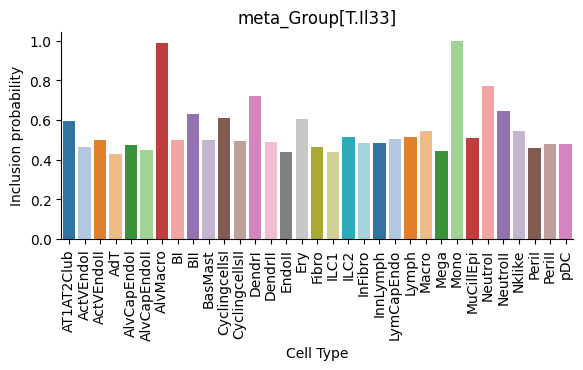

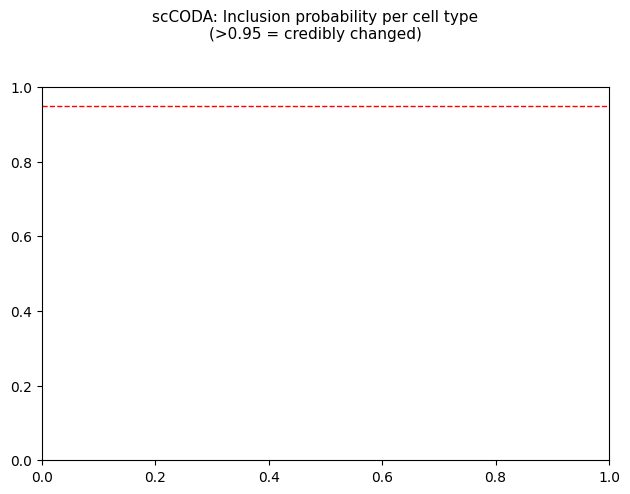

Saved: cell_proportion_sccoda_barplot.png


In [46]:
# ── scCODA diagnostic plots ───────────────────────────────────────────────────
if SCCODA_AVAILABLE:
    import matplotlib.pyplot as plt

    try:
        ax = sccoda_model.plot_effects_barplot(
            sccoda_data,
            modality_key = 'rna',
            parameter    = 'Inclusion probability'
        )
        plt.suptitle('scCODA: Inclusion probability per cell type\n(>0.95 = credibly changed)',
                     y=1.02, fontsize=11)
        plt.axhline(0.95, color='red', linestyle='--', linewidth=1, label='95% threshold')
        plt.tight_layout()
        plt.savefig('../../../../html_local/report_figures/cell_proportion_sccoda_barplot.png',
                    dpi=200, bbox_inches='tight', facecolor='white')
        plt.show()
        plt.close()
        print('Saved: cell_proportion_sccoda_barplot.png')
    except Exception as e:
        print(f'Could not generate scCODA barplot: {e}')

## 10. Method 7 — sccomp (Dirichlet-multinomial GLM with outlier detection)

**sccomp** [Mangiola et al. 2023, *PNAS*] is the most feature-rich method in this notebook. It fits a **Dirichlet-multinomial generalised linear model** via Stan (Bayesian MCMC), which:

1. **Correctly models compositionality** — like scCODA, proportions are modelled jointly, not independently per cluster.
2. **Does not require a reference cell type** — a key advantage over scCODA.
3. **Tests differential variability as well as differential composition** — it can detect clusters that become more or less variable between conditions, independently of mean proportion changes.
4. **Has built-in outlier detection** via a two-component mixture model — particularly valuable with small n (3 vs 2) where a single outlier replicate can dominate results.
5. **Produces credible intervals and FDR-controlled results** from the posterior distribution.

### Outputs
- `c_effect`: log-fold change in composition (mean proportion)
- `c_FDR`: FDR for differential composition
- `v_effect`: log-fold change in variability (variance of proportion)
- `v_FDR`: FDR for differential variability

> Mangiola S, Roth-Schulze AJ, Trussart M, et al. sccomp: Robust differential composition and variability analysis for single-cell data. *PNAS*. 2023. https://doi.org/10.1073/pnas.2203828120

In [47]:
%%R
library(sccomp)

# ── sccomp requires a data frame with one row per cell ────────────────────────
# Columns needed: cell type, sample ID, group covariate
sccomp_input <- data.frame(
  cell_group = meta$clusterName,
  sample     = meta$sampleName,
  group      = meta$meta_Group,
  stringsAsFactors = FALSE
)

cat('sccomp input (first 6 rows):\n')
print(head(sccomp_input))
cat(sprintf('\nTotal cells: %d\n', nrow(sccomp_input)))

sccomp input (first 6 rows):
  cell_group          sample group
1    InFibro Myc2W_Ctrl_CRE1  Ctrl
2         BI Myc2W_Ctrl_CRE1  Ctrl
3      Macro Myc2W_Ctrl_CRE1  Ctrl
4      EndoI Myc2W_Ctrl_CRE1  Ctrl
5   AlvMacro Myc2W_Ctrl_CRE1  Ctrl
6      EndoI Myc2W_Ctrl_CRE1  Ctrl

Total cells: 47054


In [48]:
%%R
# dir.create("/nemo/stp/babs/working/boeings/package_caches/cmdstan", recursive = TRUE, showWarnings = FALSE)
# cmdstanr::install_cmdstan(
#     dir = "/nemo/stp/babs/working/boeings/package_caches/cmdstan",
#     cores = 4
# )

NULL


In [49]:
%%R
# Set cmdstan path
# cmdstan_dir <- "/nemo/stp/babs/working/boeings/package_caches/cmdstan"
# cmdstanr::set_cmdstan_path(file.path(cmdstan_dir, list.files(cmdstan_dir)[1]))
# cat("CmdStan version:", cmdstanr::cmdstan_version(), "\n")

# # Fix sccomp cache path
# sccomp_cache <- "/nemo/stp/babs/working/boeings/package_caches/sccomp_models"
# dir.create(sccomp_cache, recursive = TRUE, showWarnings = FALSE)
# Sys.setenv(SCCOMP_CACHE = sccomp_cache)

NULL


In [50]:
%%R
renv::install("stan-dev/cmdstanr")
renv::snapshot()

The following package(s) will be installed:
- cmdstanr [stan-dev/cmdstanr]
These packages will be installed into "/nemo/stp/babs/working/boeings/package_caches/R/library/linux-ubuntu-jammy/R-4.5/x86_64-pc-linux-gnu".



Do you want to proceed? [Y/n]:  y



# Installing packages --------------------------------------------------------
- Installing cmdstanr 0.9.0.9000 ...            OK [linked from cache]
- The lockfile is already up to date.


In [51]:
%%R
print(packageVersion("cmdstanr"))
print(packageVersion("sccomp"))

cmdstanr::set_cmdstan_path("/nemo/stp/babs/working/boeings/package_caches/cmdstan/cmdstan-2.38.0")
cmdstanr::cmdstan_version()

[1] ‘0.9.0.9000’
[1] ‘2.2.0’
[1] "2.38.0"


CmdStan path set to: /nemo/stp/babs/working/boeings/package_caches/cmdstan/cmdstan-2.38.0


In [52]:
%%R
sccomp_cache <- "/nemo/stp/babs/working/boeings/package_caches/sccomp_models"
dir.create(sccomp_cache, recursive = TRUE, showWarnings = FALSE)
Sys.setenv(SCCOMP_CACHE = sccomp_cache)

In [53]:
%%R
print(packageVersion("cmdstanr"))
print(packageVersion("sccomp"))
cmdstanr::cmdstan_version()

[1] ‘0.9.0.9000’
[1] ‘2.2.0’
[1] "2.38.0"


In [54]:
%%R
new_stan_compile_model <- function(model, verbose = TRUE, quiet = FALSE, 
    pedantic = FALSE, include_paths = NULL, user_header = NULL, 
    cpp_options = list(), stanc_options = list(), 
    force_recompile = FALSE, threads = FALSE, ...) {
    if (verbose) {
        old <- getOption("cmdstanr_verbose")
        on.exit(options(cmdstanr_verbose = old))
        options(cmdstanr_verbose = TRUE)
    }
    cmdstanr::cmdstan_model(
        stan_file = model,
        compile = TRUE,
        quiet = quiet,
        pedantic = pedantic,
        include_paths = include_paths,
        user_header = user_header,
        cpp_options = cpp_options,
        stanc_options = stanc_options,
        force_recompile = force_recompile,
        ...
    )
    invisible()
}

utils::assignInNamespace("stan_compile_model", new_stan_compile_model, ns = "instantiate")
cat("Patch applied.\n")

Patch applied.


In [55]:
%%R
colnames(sccomp_input)

[1] "cell_group" "sample"     "group"     


In [56]:
%%R
set.seed(42)

res_sccomp <- sccomp_input |>
  sccomp_estimate(
    formula_composition = ~ group,
    formula_variability = ~ group,
    .sample             = sample,
    .cell_group         = cell_group,
    bimodal_mean_variability_association = TRUE,
    cores = 1
  ) |>
  sccomp_test()

cat('=== sccomp results ===\n')
print(res_sccomp)

Path [1] :Initial log joint density = -180523.536126 
Path [1] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.793e+05      5.828e-02   3.959e+03    3.986e-02  3.986e-02      8290 -1.703e+03 -1.172e+04                   
Path [1] :Best Iter: [37] ELBO (-1703.325655) evaluations: (8290) 
Path [2] :Initial log joint density = -180642.344410 
Path [2] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.793e+05      2.596e-02   1.193e+04    2.257e-02  2.257e-02      8358 -1.697e+03 -4.151e+05                   
Path [2] :Best Iter: [34] ELBO (-1697.371185) evaluations: (8358) 
Path [3] :Initial log joint density = -180722.566958 
Path [3] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100      -1.793e+05      1.1

sccomp says: count column is an integer. The sum-constrained beta binomial model will be used
sccomp says: estimation
sccomp says: the composition design matrix has columns: (Intercept), groupIl33
sccomp says: the variability design matrix has columns: (Intercept), groupIl33
Loading model from cache...
sccomp says: to do hypothesis testing run `sccomp_test()`,
  the `test_composition_above_logit_fold_change` = 0.1 equates to a change of ~10%, and
  0.7 equates to ~100% increase, if the baseline is ~0.1 proportion.
  Use `sccomp_proportional_fold_change` to convert c_effect (linear) to proportion difference (non-linear).
In addition: Warning messages:
1: The `.sample` argument of `sccomp_estimate()` is deprecated as of sccomp 2.1.1.
ℹ .sample argument (which were tidy evaluations, i.e. .sample = my_sample) have
  been deprecated in favour of sample (without trailing dot, and which is now a
  character string, i.e. sample = "my_sample")
This warning is displayed once per session.
Call `l

In [57]:
%%R
cat('Unique parameter values:\n')
print(unique(as.data.frame(res_sccomp)$parameter))
cat('\ngroup_B =', group_B, '\n')

Unique parameter values:
[1] "(Intercept)" "groupIl33"  

group_B = Il33 


Using contrast parameter(s): groupIl33 
Saved: cell_proportion_sccomp_composition.png


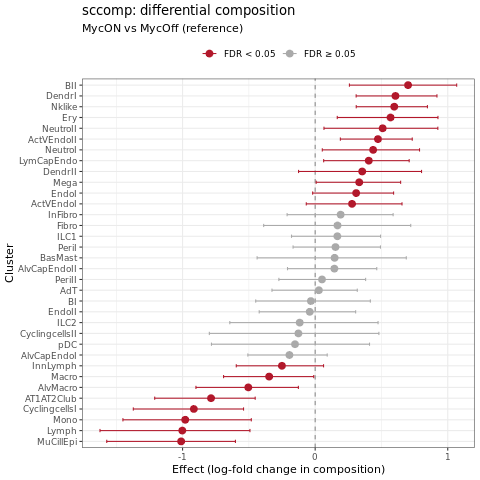

In [58]:
%%R
options(repr.plot.width = 14, repr.plot.height = 6)

sccomp_df <- as.data.frame(res_sccomp)

# The non-intercept parameter IS the comparison of interest
contrast_param <- unique(sccomp_df$parameter[sccomp_df$parameter != '(Intercept)'])
cat('Using contrast parameter(s):', paste(contrast_param, collapse = ', '), '\n')

p_sccomp <- sccomp_df %>%
  filter(parameter != '(Intercept)') %>%
  mutate(
    sig_label  = ifelse(!is.na(c_FDR) & c_FDR < 0.05, 'FDR < 0.05', 'FDR \u2265 0.05'),
    cell_group = reorder(cell_group, c_effect)
  ) %>%
  ggplot(aes(x = c_effect, y = cell_group, colour = sig_label)) +
  geom_vline(xintercept = 0, linetype = 'dashed', colour = '#888888') +
  geom_errorbar(
    aes(xmin = c_lower, xmax = c_upper),
    width = 0.3, orientation = 'y'
  ) +
  geom_point(size = 3) +
  scale_colour_manual(
    values = c('FDR \u2265 0.05' = '#AAAAAA', 'FDR < 0.05' = '#B2182B')
  ) +
  labs(
    title    = 'sccomp: differential composition',
    subtitle = sprintf('MycON vs MycOff (reference)'),
    x        = 'Effect (log-fold change in composition)',
    y        = 'Cluster',
    colour   = NULL
  ) +
  theme_bw(base_size = 11) +
  theme(legend.position = 'top')

print(p_sccomp)
ggsave('../../../../html_local/report_figures/cell_proportion_sccomp_composition.png',
       p_sccomp, width = 10, height = 5, dpi = 200, bg = 'white')
cat('Saved: cell_proportion_sccomp_composition.png\n')

In [59]:
%%R
# ── Extract sccomp composition results for the comparison table ───────────────
tryCatch({
  sccomp_df <- as.data.frame(res_sccomp)

  # Filter to the group B coefficient rows (the contrast of interest)
  sccomp_comp <- sccomp_df %>%
    filter(grepl(paste0('^', group_B), parameter)) %>%
    select(cell_group, any_of(c('c_effect', 'c_lower', 'c_upper', 'c_FDR',
                                 'v_effect', 'v_lower', 'v_upper', 'v_FDR'))) %>%
    rename(clusterName = cell_group)

  cat('=== sccomp composition + variability results ===\n')
  print(sccomp_comp)

  write.csv(sccomp_comp,
            '../../../../html_local/report_figures/cell_proportion_sccomp.csv',
            row.names = FALSE)
  cat('\nSaved: cell_proportion_sccomp.csv\n')

  # Store for merging into comparison table
  res_sccomp_comp <<- sccomp_comp

}, error = function(e) {
  cat('Could not extract sccomp results:', conditionMessage(e), '\n')
  res_sccomp_comp <<- NULL
})

=== sccomp composition + variability results ===
[1] clusterName c_effect    c_lower     c_upper     c_FDR       v_effect   
[7] v_lower     v_upper     v_FDR      
<0 rows> (or 0-length row.names)

Saved: cell_proportion_sccomp.csv


## 11. Compile and compare results across methods

In [60]:
%%R
# Detect the actual PropMean columns dynamically
prop_mean_cols <- grep('^PropMean\\.', colnames(res_propeller_logit), value = TRUE)
cat('PropMean columns:', paste(prop_mean_cols, collapse = ', '), '\n')

prop_logit_tbl <- res_propeller_logit %>%
  tibble::rownames_to_column('clusterName') %>%
  select(clusterName, all_of(prop_mean_cols), P.Value, FDR) %>%
  rename(mean_A = all_of(prop_mean_cols[1]),
         mean_B = all_of(prop_mean_cols[2]),
         p_value = P.Value, p_adj = FDR) %>%
  mutate(method = 'propeller_logit')

prop_asin_tbl <- res_propeller_asin %>%
  tibble::rownames_to_column('clusterName') %>%
  select(clusterName, all_of(prop_mean_cols), P.Value, FDR) %>%
  rename(mean_A = all_of(prop_mean_cols[1]),
         mean_B = all_of(prop_mean_cols[2]),
         p_value = P.Value, p_adj = FDR) %>%
  mutate(method = 'propeller_asin')

betareg_tbl <- res_betareg %>%
  select(clusterName, p_value, p_adj) %>%
  mutate(method = 'betareg')

wilcox_tbl <- res_wilcoxon %>%
  select(clusterName, mean_A, mean_B, p_value, p_adj) %>%
  mutate(method = 'wilcoxon')

perm_tbl <- res_permutation %>%
  select(clusterName, mean_A, mean_B, p_value, p_adj) %>%
  mutate(method = 'permutation')

# ── sccomp: extract contrast rows and rename cell_group -> clusterName ────────
sccomp_tbl <- as.data.frame(res_sccomp) %>%
  filter(parameter != '(Intercept)') %>%
  select(cell_group, c_effect, c_FDR) %>%
  rename(clusterName = cell_group,
         sccomp_c_effect = c_effect,
         sccomp_c_FDR    = c_FDR)

# ── Wide comparison table ─────────────────────────────────────────────────────
pval_wide <- prop_logit_tbl %>%
  select(clusterName, mean_A, mean_B) %>%
  left_join(prop_logit_tbl %>% select(clusterName, p_value) %>% rename(p_propeller_logit = p_value), by = 'clusterName') %>%
  left_join(prop_asin_tbl  %>% select(clusterName, p_value) %>% rename(p_propeller_asin  = p_value), by = 'clusterName') %>%
  left_join(betareg_tbl    %>% select(clusterName, p_value) %>% rename(p_betareg         = p_value), by = 'clusterName') %>%
  left_join(wilcox_tbl     %>% select(clusterName, p_value) %>% rename(p_wilcoxon        = p_value), by = 'clusterName') %>%
  left_join(perm_tbl       %>% select(clusterName, p_value) %>% rename(p_permutation     = p_value), by = 'clusterName') %>%
  left_join(sccomp_tbl, by = 'clusterName') %>%
  arrange(p_propeller_logit)

cat('=== Comparison of p-values / FDR across methods ===\n')
print(pval_wide)

write.csv(pval_wide, '../../../../html_local/report_figures/cell_proportion_pvalues_all_methods.csv', row.names = FALSE)
cat('\nSaved: cell_proportion_pvalues_all_methods.csv\n')

PropMean columns: PropMean.Ctrl, PropMean.Il33 
=== Comparison of p-values / FDR across methods ===
      clusterName      mean_A       mean_B p_propeller_logit p_propeller_asin
1   CyclingcellsI 0.014561319 0.0043617180        0.01133567      0.033137323
2        NeutroII 0.007791805 0.0197060579        0.01475993      0.046984987
3             BII 0.008219384 0.0196609675        0.01620459      0.011870328
4            Mono 0.121872096 0.0342080198        0.01772727      0.076088820
5        AlvMacro 0.122280294 0.0600827846        0.02905403      0.002796699
6           Lymph 0.001865478 0.0009113641        0.03982475      0.294381625
7             Ery 0.010276471 0.0224750244        0.04213016      0.044376077
8      AT1AT2Club 0.019680676 0.0071944816        0.05063809      0.072428310
9          Nklike 0.016231452 0.0269583269        0.11200029      0.042355155
10           ILC2 0.002565544 0.0054944252        0.11369334      0.237511132
11 CyclingcellsII 0.001842358 0.0033749442

In [61]:
import os, pandas as pd

results_csv = '../../../../html_local/report_figures/cell_proportion_pvalues_all_methods.csv'

sccoda_res = pd.read_csv('/tmp/sccoda_results.csv', index_col=0)
sccoda_res.index.name = 'clusterName'
sccoda_res = sccoda_res.reset_index()
print('scCODA columns:', sccoda_res.columns.tolist())
print(sccoda_res.head())

scCODA columns: ['clusterName', 'Final Parameter', 'HDI 3%', 'HDI 97%', 'SD', 'Inclusion probability', 'Expected Sample', 'log2-fold change']
   clusterName  Final Parameter  HDI 3%  HDI 97%     SD  \
0   AT1AT2Club              0.0  -1.019    0.293  0.326   
1    ActVEndoI              0.0  -0.530    0.647  0.213   
2   ActVEndoII              0.0  -0.408    0.829  0.247   
3          AdT              0.0  -0.556    0.306  0.164   
4  AlvCapEndoI              0.0  -0.715    0.383  0.220   

   Inclusion probability  Expected Sample  log2-fold change  
0                0.59550        93.500568          0.155619  
1                0.46310        90.104266          0.155619  
2                0.49715        72.527624          0.155619  
3                0.42945       324.396818          0.155619  
4                0.47175       131.232100          0.155619  


In [62]:
import os, pandas as pd

results_csv = '../../../../html_local/report_figures/cell_proportion_pvalues_all_methods.csv'

if not os.path.exists(results_csv):
    print(f'WARNING: {results_csv} not found — did the R cell complete successfully?')
else:
    if SCCODA_AVAILABLE and os.path.exists('/tmp/sccoda_results.csv'):
        sccoda_res = pd.read_csv('/tmp/sccoda_results.csv', index_col=0)
        sccoda_res.index.name = 'clusterName'
        sccoda_res = sccoda_res.reset_index()

        pval_wide = pd.read_csv(results_csv)

        # Use only columns that actually exist
        keep_cols = ['clusterName']
        rename_map = {}
        if 'Inclusion probability' in sccoda_res.columns:
            keep_cols.append('Inclusion probability')
            rename_map['Inclusion probability'] = 'sccoda_inclusion_prob'
        if 'Credible Effect' in sccoda_res.columns:
            keep_cols.append('Credible Effect')
            rename_map['Credible Effect'] = 'sccoda_credible'
        else:
            # Derive from inclusion probability threshold
            sccoda_res['sccoda_credible'] = sccoda_res.get('Inclusion probability', 0) >= 0.95
            keep_cols.append('sccoda_credible')

        sccoda_merge = sccoda_res[keep_cols].rename(columns=rename_map)

        pval_wide = pval_wide.merge(sccoda_merge, on='clusterName', how='left')
        pval_wide.to_csv(results_csv, index=False)
        print('scCODA results merged into comparison table.')
        print(pval_wide.to_string())
    else:
        pval_wide = pd.read_csv(results_csv)
        print('scCODA results not available — comparison table contains R methods only.')
        print(pval_wide.to_string())

scCODA results merged into comparison table.
       clusterName    mean_A    mean_B  p_propeller_logit  p_propeller_asin  p_betareg  p_wilcoxon  p_permutation  sccomp_c_effect  sccomp_c_FDR  sccoda_inclusion_prob  sccoda_credible
0    CyclingcellsI  0.014561  0.004362           0.011336          0.033137   0.013606    0.060602       0.057143        -0.915177      0.000000                0.60930            False
1         NeutroII  0.007792  0.019706           0.014760          0.046985   0.030565    0.193931       0.114286         0.508999      0.007104                0.64545            False
2              BII  0.008219  0.019661           0.016205          0.011870   0.000018    0.030383       0.028571         0.700584      0.004750                0.62935            False
3             Mono  0.121872  0.034208           0.017727          0.076089   0.111974    0.112351       0.085714        -0.980062      0.000000                0.99645             True
4         AlvMacro  0.122280  

## 12. Visualise results

### 11a. Heatmap of p-values across methods (+ scCODA inclusion probability)

Saved: cell_proportion_pvalue_heatmap.png


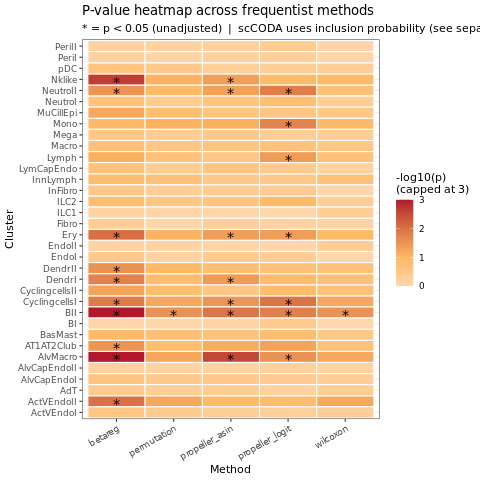

In [63]:
%%R
options(repr.plot.width = 12, repr.plot.height = 5)

# Read merged table (may include scCODA column)
pval_merged <- read.csv('../../../../html_local/report_figures/cell_proportion_pvalues_all_methods.csv',
                        check.names = FALSE)

# Identify p-value columns (all starting with p_)
p_cols <- grep('^p_', names(pval_merged), value = TRUE)

pval_long_plot <- pval_merged %>%
  select(clusterName, all_of(p_cols)) %>%
  pivot_longer(-clusterName, names_to = 'method', values_to = 'p_value') %>%
  mutate(
    method      = gsub('^p_', '', method),
    neg_log10_p = pmin(-log10(p_value), 3),
    sig_label   = ifelse(!is.na(p_value) & p_value < 0.05, '*', '')
  )

p_heatmap <- ggplot(pval_long_plot,
                    aes(x = method, y = clusterName, fill = neg_log10_p)) +
  geom_tile(colour = 'white', linewidth = 0.5) +
  geom_text(aes(label = sig_label), size = 5, colour = 'black', vjust = 0.75) +
  scale_fill_gradient2(
    low = '#F7F7F7', mid = '#FDB863', high = '#B2182B',
    midpoint = 1, na.value = 'grey80',
    name = '-log10(p)\n(capped at 3)'
  ) +
  labs(title = 'P-value heatmap across frequentist methods',
       subtitle = '* = p < 0.05 (unadjusted)  |  scCODA uses inclusion probability (see separate plot)',
       x = 'Method', y = 'Cluster') +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

print(p_heatmap)
ggsave('../../../../html_local/report_figures/cell_proportion_pvalue_heatmap.png',
       p_heatmap, width = 12, height = 5, dpi = 200, bg = 'white')
cat('Saved: cell_proportion_pvalue_heatmap.png\n')

### 11b. propeller results: volcano-style plot

Saved: cell_proportion_propeller_volcano.png


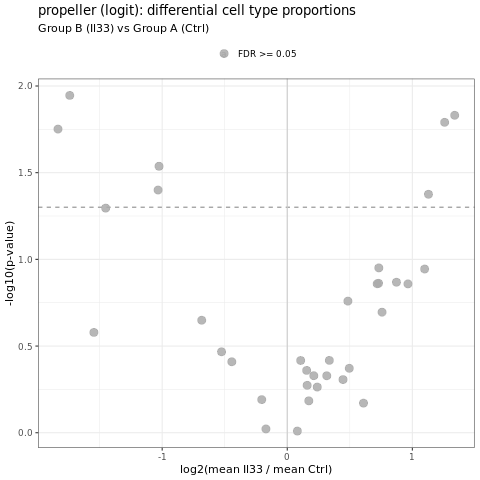

In [64]:
%%R
options(repr.plot.width = 8, repr.plot.height = 5)

prop_plot_df <- prop_logit_tbl %>%
  mutate(
    log2FC      = log2((mean_B + 1e-6) / (mean_A + 1e-6)),
    neg_log10_p = -log10(p_value),
    significant = p_adj < 0.05,
    label       = ifelse(p_adj < 0.1, clusterName, '')
  )

p_volcano <- ggplot(prop_plot_df,
                    aes(x = log2FC, y = neg_log10_p,
                        colour = significant, label = label)) +
  geom_hline(yintercept = -log10(0.05), linetype = 'dashed',
             colour = '#888888', linewidth = 0.5) +
  geom_vline(xintercept = 0, linetype = 'solid',
             colour = '#CCCCCC', linewidth = 0.5) +
  geom_point(size = 3.5, alpha = 0.85) +
  ggrepel::geom_text_repel(size = 3, fontface = 'bold',
                            box.padding = 0.4, max.overlaps = 20) +
  scale_colour_manual(values = c('FALSE' = '#AAAAAA', 'TRUE' = '#B2182B'),
                      labels = c('FDR >= 0.05', 'FDR < 0.05')) +
  labs(
    title    = 'propeller (logit): differential cell type proportions',
    subtitle = sprintf('Group B (%s) vs Group A (%s)', group_B, group_A),
    x        = sprintf('log2(mean %s / mean %s)', group_B, group_A),
    y        = '-log10(p-value)',
    colour   = NULL
  ) +
  theme_bw(base_size = 11) +
  theme(legend.position = 'top')

print(p_volcano)
ggsave('../../../../html_local/report_figures/cell_proportion_propeller_volcano.png',
       p_volcano, width = 8, height = 5, dpi = 200, bg = 'white')
cat('Saved: cell_proportion_propeller_volcano.png\n')

### 11c. Per-cluster boxplots for top hits

Saved: cell_proportion_top_clusters_boxplot.png


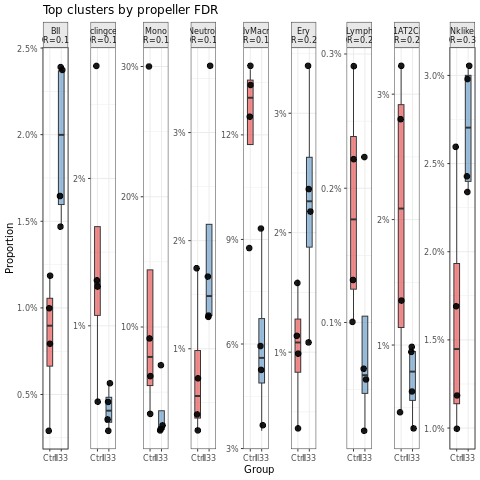

In [65]:
%%R
options(repr.plot.width = 12, repr.plot.height = 4)

top_clusters <- prop_logit_tbl %>%
  arrange(p_adj) %>%
  slice_head(n = min(9, nrow(prop_logit_tbl))) %>%
  pull(clusterName)

plot_df <- prop_long %>%
  filter(clusterName %in% top_clusters) %>%
  left_join(
    prop_logit_tbl %>% select(clusterName, p_adj),
    by = 'clusterName'
  ) %>%
  mutate(
    cluster_label = sprintf('%s\n(FDR=%.3f)', clusterName, p_adj),
    cluster_label = factor(cluster_label,
                           levels = unique(cluster_label[order(p_adj)]))
  )

p_box <- ggplot(plot_df,
                aes(x = meta_Group, y = proportion, fill = meta_Group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.5, width = 0.5) +
  geom_jitter(width = 0.12, size = 2.5, alpha = 0.9) +
  scale_fill_manual(values = c('#E41A1C', '#377EB8'), guide = 'none') +
  scale_y_continuous(labels = scales::percent_format()) +
  facet_wrap(~ cluster_label, scales = 'free_y', nrow = 1) +
  labs(title = 'Top clusters by propeller FDR',
       x = 'Group', y = 'Proportion') +
  theme_bw(base_size = 10) +
  theme(strip.background = element_rect(fill = '#E8E8E8'))

print(p_box)
ggsave('../../../../html_local/report_figures/cell_proportion_top_clusters_boxplot.png',
       p_box, width = 12, height = 4, dpi = 200, bg = 'white')
cat('Saved: cell_proportion_top_clusters_boxplot.png\n')

## 13. Save full results tables

In [66]:
%%R
write.csv(
  res_propeller_logit %>% tibble::rownames_to_column('clusterName'),
  '../../../../html_local/report_figures/cell_proportion_propeller_logit.csv', row.names = FALSE)

write.csv(
  res_propeller_asin %>% tibble::rownames_to_column('clusterName'),
  '../../../../html_local/report_figures/cell_proportion_propeller_asin.csv', row.names = FALSE)

write.csv(res_betareg,
          '../../../../html_local/report_figures/cell_proportion_betareg.csv', row.names = FALSE)

write.csv(res_wilcoxon,
          '../../../../html_local/report_figures/cell_proportion_wilcoxon.csv', row.names = FALSE)

write.csv(res_permutation,
          '../../../../html_local/report_figures/cell_proportion_permutation.csv', row.names = FALSE)

write.csv(
  as.data.frame(prop_mx) %>% tibble::rownames_to_column('sampleName'),
  '../../../../html_local/report_figures/cell_proportion_matrix.csv', row.names = FALSE)

cat('All R results saved.\n')

All R results saved.


In [67]:
# ── Save scCODA results separately ───────────────────────────────────────────
import os, shutil

if SCCODA_AVAILABLE and os.path.exists('/tmp/sccoda_results.csv'):
    shutil.copy('/tmp/sccoda_results.csv',
                '../../../../html_local/report_figures/cell_proportion_sccoda.csv')
    print('Saved: cell_proportion_sccoda.csv')
else:
    print('scCODA results not available — no file saved.')

Saved: cell_proportion_sccoda.csv


## 14. Session info

In [68]:
%%R
sessionInfo()

R version 4.5.0 (2025-04-11)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/local/lib/R/lib/libRblas.so 
LAPACK: /usr/local/lib/R/lib/libRlapack.so;  LAPACK version 3.12.1

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] tools     stats     graphics  grDevices datasets  utils     methods  
[8] base     

other attached packages:
 [1] sccomp_2.2.0       instantiate_0.2.3  speckle_1.10.0     edgeR_4.8.2       
 [5] limma_3.66.0       RColorBrewer_1.1-3 ggrepel_0.9.8      scales_1.4.0      
 [9] betareg_3.2-4      patchwork_1.3.2    ggplot

In [69]:
import sys, pertpy as pt, anndata as ad
print(f'Python: {sys.version}')
print(f'pertpy: {pt.__version__}')
print(f'anndata: {ad.__version__}')

Python: 3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
pertpy: 0.10.0
anndata: 0.11.4


---
## Summary and interpretation guide

### Which method to trust most?

With **n = 3 vs n = 2 replicates**, statistical power is inherently limited. Key considerations:

| Method | Recommended? | Reason |
|--------|-------------|--------|
| **propeller (logit)** | ✅ Primary (frequentist) | Borrows variance across clusters via limma EB; best calibrated for small n per benchmarking [Simmons 2022] |
| **propeller (arcsin)** | ✅ Secondary | Alternative transform; compare with logit for robustness |
| **sccomp** | ✅ Primary (Bayesian) | Dirichlet-multinomial GLM; no reference cell type needed; tests composition AND variability; outlier-robust; published in PNAS 2023 |
| **scCODA** | ✅ Bayesian alternative | Also compositional; requires reference cell type; compare with sccomp |
| **Beta regression** | ⚠️ Supplementary | Correct distributional model but MLE unstable with n=5 total |
| **Wilcoxon** | ⚠️ Sanity check | Min p-value = 0.1; use only to confirm direction |
| **Permutation** | ✅ Exact baseline | No distributional assumptions; min p-value = 0.1 with n=3+2 |

### sccomp-specific notes
- **No reference cell type required** — unlike scCODA, sccomp estimates all clusters jointly without needing to fix one as a reference.
- **Differential variability** (`v_effect`, `v_FDR`): a cluster can be significant for variability but not composition, or vice versa. Both are biologically meaningful.
- **Outlier detection**: sccomp flags replicate samples that behave as outliers for a given cluster. With n=3+2, inspect these flags carefully — a single outlier can be the difference between significance and non-significance.
- **Stan compilation**: the first run compiles the Stan model (~1-2 min). Subsequent runs in the same session are fast.

### scCODA-specific notes
- **Reference cell type**: choose a biologically stable cluster. Run with 2–3 candidates and check consistency.
- **Significance criterion**: posterior inclusion ≥ 95% (credible interval excluding zero), not a p-value.

### Interpreting results with small n
- **FDR < 0.05** is stringent; consider **FDR < 0.1** or **unadjusted p < 0.05** as exploratory thresholds.
- The minimum achievable p-value for Wilcoxon and permutation tests with n=3 vs n=2 is **0.1** (two-sided).
- Concordance between propeller (frequentist) and sccomp/scCODA (Bayesian compositional) is the strongest evidence for a real finding.
- Discordance between independent-cluster methods (propeller) and compositional methods (sccomp/scCODA) may indicate a compositional artefact.

### References
1. Phipson B et al. (2022) propeller. *Bioinformatics*. https://doi.org/10.1093/bioinformatics/btac582
2. Mangiola S et al. (2023) sccomp. *PNAS*. https://doi.org/10.1073/pnas.2203828120
3. Büttner M et al. (2021) scCODA. *Nature Communications*. https://doi.org/10.1038/s41467-021-27150-6
4. Simmons SK (2022) Cell Type Composition Analysis benchmarking. *bioRxiv*. https://doi.org/10.1101/2022.02.04.479123
5. Dann E et al. (2021) Milo. *Nature Biotechnology*. https://doi.org/10.1038/s41587-021-01033-z